#  Évaluation du potentiel foncier agricole — SCOT RPB
## Calcul de l'Indice de Qualité Économique (IQE) à partir des micro-données RICA 2024

**Auteurs :** MONDOR Loïc · BOHOU Christ · SOMASUNTHARAM Vaithehie  
**Formation :** Master GEORISK — Université Gustave Eiffel  
**Année :** 2025–2026  
**Source scientifique :** Agreste — Réseau d'Information Comptable Agricole (RICA 2024)  
Ministère de l'Agriculture et de la Souveraineté Alimentaire — 7 250 exploitations France entière

---
## Objectif

Ce notebook calcule l'**Indice de Qualité Économique (IQE)** pour chaque parcelle agricole du SCOT Rhône Provence Baronnies en :

1. **Extrayant les données économiques** des micro-données RICA 2024 (variables PBV3XXXX / SUT3XXXX)
2. **Calculant le Produit Brut médian €/ha** pour chaque type de culture
3. **Construisant une table de scoring** (1-5) basée sur les seuils économiques
4. **Attribuant un score IQE** (0-1) à chaque parcelle du RPG
5. **Exportant les résultats** en GeoPackage pour intégration QGIS

---
## Méthodologie CGAAER 2020

L'IQE représente **40%** de l'IQAE final (Indice de Qualité Agro-Économique) :
```
IQAE = 0.60 × IQA + 0.40 × IQE
```

| Score | Niveau | Seuil PB médian | IQE normalisé |
|-------|--------|-----------------|---------------|
| 5 | Très haute valeur | > 15 000 €/ha | 1.00 |
| 4 | Haute valeur | 8 000 – 15 000 €/ha | 0.75 |
| 3 | Valeur moyenne | 4 000 – 8 000 €/ha | 0.50 |
| 2 | Faible valeur | 2 000 – 4 000 €/ha | 0.25 |
| 1 | Très faible valeur | < 2 000 €/ha | 0.00 |

---
## Fichiers requis

| Fichier | Description | Source |
|---------|-------------|--------|
| `RICAMicroDonnees2024-v2.zip` | Micro-données RICA 2024 | Agreste |
| `RPG_pac_RPB.gpkg` | Parcelles RPG PAC SCOT RPB | IGN |
| `TUP_SCoT_RPB.gpkg` | Périmètre SCOT (optionnel) | DDT |

## 📦 Cellule 1 — Imports et vérification des fichiers

In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════
RICA_ZIP   = 'RICAMicroDonnees2024-v2.zip'
RPG_PATH   = 'RPG_pac_RPB.gpkg'
SCOT_PATH  = 'TUP_SCoT_RPB.gpkg'
OUTPUT_GPK = 'RPG_IQE_SCOT_RPB.gpkg'
OUTPUT_CSV = 'scoring_IQE_RICA2024.csv'

# ── Vérification des fichiers ────────────────────────────────────────────
print('=== Vérification des fichiers ===')
for f in [RICA_ZIP, RPG_PATH, SCOT_PATH]:
    if os.path.exists(f):
        size = os.path.getsize(f)/1e6 if os.path.isfile(f) else 0
        print(f'  Trouvé  {f}  ({size:.1f} Mo)')
    else:
        print(f'  MANQUANT  {f}')

print('\nBibliothèques :')
for lib in ['pandas', 'geopandas', 'numpy', 'matplotlib']:
    try:
        mod = __import__(lib)
        print(f'   {lib} {mod.__version__}')
    except:
        print(f'   {lib} — pip install {lib}')

=== Vérification des fichiers ===
  Trouvé  RICAMicroDonnees2024-v2.zip  (4.2 Mo)
  Trouvé  RPG_pac_RPB.gpkg  (66.2 Mo)
  Trouvé  TUP_SCoT_RPB.gpkg  (229.2 Mo)

Bibliothèques :
   pandas 2.3.3
   geopandas 1.1.2
   numpy 2.3.3
   matplotlib 3.10.6


##  Cellule 2 — Ouverture et lecture du ZIP RICA 2024

In [2]:
# ── Lister le contenu du ZIP ──────────────────────────────────────────────
print('=== Contenu du ZIP RICA ===')
with zipfile.ZipFile(RICA_ZIP, 'r') as z:
    for info in z.infolist():
        print(f'  {info.filename}  ({info.file_size/1e6:.1f} Mo)')

# ── Charger le CSV des micro-données ───────────────────────────────────────
print('\nChargement des micro-données RICA...')
with zipfile.ZipFile(RICA_ZIP, 'r') as z:
    csv_files = [f for f in z.namelist() if f.endswith('.csv')]
    csv_name = csv_files[0]
    print(f'  Fichier CSV : {csv_name}')
    with z.open(csv_name) as f:
        rica = pd.read_csv(f, sep=';', decimal=',', low_memory=False)

print(f'\n RICA chargé : {rica.shape[0]:,} exploitations × {rica.shape[1]:,} variables')
print(f'\nPremières colonnes : {list(rica.columns[:15])}')

=== Contenu du ZIP RICA ===
  Methodologie fichier RICA france 2024.docx  (0.1 Mo)
  RICA2024_dictionnaire_FMD.xlsx  (0.2 Mo)
  Rica_France_micro_Donnees_ex2024.csv  (19.9 Mo)

Chargement des micro-données RICA...
  Fichier CSV : Rica_France_micro_Donnees_ex2024.csv

 RICA chargé : 7,250 exploitations × 985 variables

Premières colonnes : ['IDNUM', 'MILEX', 'PBUCE', 'CDEXE', 'OTEXE', 'OTE64F', 'OTEFDD', 'OTEFDA', 'EXTR2', 'NREG', 'REGIO', 'ZALTI', 'ZDEFA', 'ZENVI', 'RIMPO']


##  Cellule 3 — Exploration du RICA : structure et variables clés

In [3]:
# ── Variables clés pour l'analyse ─────────────────────────────────────────
vars_cles = {
    'IDNUM':  'Identifiant exploitation',
    'NREG':   'Code région (INSEE)',
    'REGIO':  'Région (ancienne)',
    'OTEXE':  'Orientation technico-économique (OTEX)',
    'PBUCE':  'Production Brute Standard (PBS) €',
    'SAUTI':  'Surface Agricole Utile (SAU) ha',
    'PBRTO':  'Production brute totale €',
    'EBEXP':  'Excédent Brut d\'Exploitation €',
    'CINTR':  'Consommations intermédiaires €',
    'ZALTI':  'Zone altitude (1=montagne 2=piedmont 3=plaine)',
    'ZDEFA':  'Zone défavorisée',
}

print('=== Variables clés disponibles ===')
for col, desc in vars_cles.items():
    status = 'ok' if col in rica.columns else 'X'
    print(f'  {status} {col:<8} : {desc}')

# ── Répartition par OTEX ───────────────────────────────────────────────────
otex_map = {
    15: 'Grandes cultures (COP)', 16: 'Céréales spécialisées',
    28: 'Maraîchage', 29: 'Horticulture/Fleurs',
    37: 'Viticulture', 38: 'Fruits',
    39: 'Autres cultures permanentes',
    45: 'Bovin lait', 46: 'Bovin viande',
    47: 'Ovins/Caprins', 48: 'Granivores',
    50: 'Polyculture', 61: 'Poly-élevage',
    73: 'Grandes cultures mixtes', 74: 'Cultures-élevage',
    83: 'Bovin mixte', 84: 'Polyélevage'
}

print('\n=== Répartition par OTEX ===')
otex_count = rica['OTEXE'].value_counts().reset_index()
otex_count.columns = ['OTEX', 'N']
otex_count['Libellé'] = otex_count['OTEX'].map(otex_map).fillna('Autre')
print(otex_count.head(15).to_string(index=False))

=== Variables clés disponibles ===
  ok IDNUM    : Identifiant exploitation
  ok NREG     : Code région (INSEE)
  ok REGIO    : Région (ancienne)
  ok OTEXE    : Orientation technico-économique (OTEX)
  ok PBUCE    : Production Brute Standard (PBS) €
  ok SAUTI    : Surface Agricole Utile (SAU) ha
  ok PBRTO    : Production brute totale €
  ok EBEXP    : Excédent Brut d'Exploitation €
  ok CINTR    : Consommations intermédiaires €
  ok ZALTI    : Zone altitude (1=montagne 2=piedmont 3=plaine)
  ok ZDEFA    : Zone défavorisée

=== Répartition par OTEX ===
 OTEX   N                     Libellé
   37 948                 Viticulture
   45 832                  Bovin lait
   15 770      Grandes cultures (COP)
   46 732                Bovin viande
   50 717                 Polyculture
   16 579       Céréales spécialisées
   48 518                  Granivores
   39 432 Autres cultures permanentes
   83 418                 Bovin mixte
   28 306                  Maraîchage
   47 215            

## 📊 Cellule 4 — Calcul du Produit Brut €/ha par culture

**Principe :** Pour chaque culture, on divise la valeur de la production (`PBV3XXXX`) par la surface (`SUT3XXXX`).  
On utilise la **médiane** (plus robuste que la moyenne face aux outliers).

Les variables RICA suivent la nomenclature :
- `PBV3XXXX` : Produit Brut Végétal pour la culture XXXX (€)
- `SUT3XXXX` : Surface Utilisée pour la culture XXXX (ha)

In [4]:
# ══════════════════════════════════════════════════════════════════════════
# DICTIONNAIRE RICA → RPG : correspondance cultures
# Format : 'CODE_RICA': (col_pb, col_surface, [codes_RPG], 'libellé')
# ══════════════════════════════════════════════════════════════════════════

cultures_rica = {
    # Céréales
    'BLET': ('PBV3BLET', 'SUT3BLET', ['BTH','BPS','BTA'],           'Blé tendre'),
    'BLED': ('PBV3BLED', 'SUT3BLED', ['BDH','BDP'],                 'Blé dur'),
    'MAIS': ('PBV3MAIS', 'SUT3MAIS', ['MIS','MID','MIG','MGS'],     'Maïs grain'),
    'ORGE': ('PBV3ORGE', 'SUT3ORGE', ['ORH','ORP','OH2','ORG'],     'Orge'),
    'ACER': ('PBV3ACER', 'SUT3ACER', ['ACR','AGR','TRI','TRH','TRP','SEI','SEP','SEG','AVN','AVP','AVO','BOR','SOG','SOR','SGR'], 'Autres céréales'),
    
    # Oléagineux
    'TOUR': ('PBV3TOUR', 'SUT3TOUR', ['TRN','TSH','TOU'],           'Tournesol'),
    'COLZ': ('PBV3COLZ', 'SUT3COLZ', ['CZH','CZP','CPL'],           'Colza'),
    'SOJA': ('PBV3SOJA', 'SUT3SOJA', ['SJO','SOJ'],                 'Soja'),
    
    # Protéagineux
    'POIP': ('PBV3POIP', 'SUT3POIP', ['PIS','PSH'],                 'Pois protéagineux'),
    'FEVE': ('PBV3FEVE', 'SUT3FEVE', ['FVE','FAB','LEN'],           'Fèves/Féveroles/Lentilles'),
    'LEGS': ('PBV3LEGS', 'SUT3LEGS', ['LSS','LSC'],                 'Légumes secs'),
    
    # Cultures industrielles
    'PDET': ('PBV3PDET', 'SUT3PDET', ['PTC','PTA','PTF','PDT'],     'Pomme de terre'),
    'SEME': ('PBV3SEME', 'SUT3SEME', ['SEM','SGH','SGP'],           'Semences'),
    
    # Fourrages
    'MAIF': ('PBV3MAIF', 'SUT3MAIF', ['MIE','MEI','MEH','MFO'],     'Maïs fourrage'),
    'LUZE': ('PBV3LUZE', 'SUT3LUZE', ['LUZ','ALF'],                 'Luzerne'),
    'FOUR': ('PBV3FOUR', 'SUT3FOUR', ['FOU','RGA','RGH','RGI','SAI','TRE','VES','SAF','MLG','MLF'], 'Autres fourrages'),
    
    # Arboriculture
    'POMM': ('PBV3POMM', 'SUT3POMM', ['POM','PPO'],                 'Pommes'),
    'POIR': ('PBV3POIR', 'SUT3POIR', ['POI','POP'],                 'Poires'),
    'CERI': ('PBV3CERI', 'SUT3CERI', ['CER','CRC'],                 'Cerises'),
    'PRUN': ('PBV3PRUN', 'SUT3PRUN', ['PRN','PNP','PRU'],           'Pruneaux/Prunes'),
    'ABRI': ('PBV3ABRI', 'SUT3ABRI', ['ARI','ARC','ABR'],           'Abricots'),
    'PECH': ('PBV3PECH', 'SUT3PECH', ['PCH','PCP','NEP'],           'Pêches/Nectarines'),
    'AFRU': ('PBV3AFRU', 'SUT3AFRU', ['FRA','KIW','NOX','NOY','PEB','AAR','ARP','PEP'], 'Autres fruits'),
    'OLIV': ('PBV3OLIV', 'SUT3OLIV', ['OLV','OLC','OLI'],           'Olives'),
    'AMEN': ('PBV3AMEN', 'SUT3AMEN', ['AMN'],                       'Amandes'),
    'CHAT': ('PBV3CHAT', 'SUT3CHAT', ['CHA'],                       'Châtaignes'),
    
    # Viticulture
    'VRES': ('PBV3VRES', 'SUT3VRES', ['VRN','VRC','VRS','VRG'],     'Vigne AOC/AOP'),
    'VIGP': ('PBV3VIGP', 'SUT3VIGP', ['VIG','VIN','VAO'],           'Vigne IGP/autre'),
    
    # Maraîchage
    'LEGF': ('PBV3LEGF', 'SUT3LEGF', ['LLG','LEG','MIX','ACS','SAR','MEL','MDI','PVT','AIL','PWT','MLO','ASP','ART','CGT','AUB','HAV','SAL','TOM','TTH','HAR','EPI','CHO','OIG','CAR','NAV','BET','CEL','POA','CHS','EPD','FEV','POT'], 'Légumes frais'),
    
    # Fleurs et PPAM
    'FLEU': ('PBV3FLEU', 'SUT3FLEU', ['FLA','FLO','FLP'],           'Fleurs'),
    'PPAM': ('PBV3PPAM', 'SUT3PPAM', ['LAV','LVN','LVD','PPM','AIA','PME'], 'PPAM/Lavande'),
    
    # Truffes (spécifique territoire)
    'TRUF': ('PBV3TRUF', 'SUT3TRUF', ['TRU'],                       'Truffes'),
}

print(f' {len(cultures_rica)} cultures RICA définies')
print(f'   Codes RPG couverts : {sum(len(v[2]) for v in cultures_rica.values())}')

 32 cultures RICA définies
   Codes RPG couverts : 143


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# CALCUL DU PB/HA MÉDIAN PAR CULTURE
# ══════════════════════════════════════════════════════════════════════════

resultats = []
codes_rpg_scores = {}  # Dictionnaire final CODE_RPG → score

print('=== Calcul du Produit Brut €/ha par culture ===')
print(f'{"Culture":<25} {"N expl.":<9} {"PB moyen €/ha":<16} {"PB médian €/ha":<17} {"Q25-Q75"}')
print('-' * 90)

for code_rica, (pb_col, su_col, rpg_codes, label) in cultures_rica.items():
    # Vérifier si les colonnes existent
    if pb_col in rica.columns and su_col in rica.columns:
        # Filtrer les exploitations avec données valides
        sub = rica[(rica[su_col] > 0) & (rica[pb_col] > 0)].copy()
        sub['pb_ha'] = sub[pb_col] / sub[su_col]
        
        # Supprimer les outliers
        sub = sub[sub['pb_ha'].between(100, 300000)]
        
        if len(sub) >= 5:  # Au moins 5 exploitations
            pb_mean = sub['pb_ha'].mean()
            pb_median = sub['pb_ha'].median()
            pb_q25 = sub['pb_ha'].quantile(0.25)
            pb_q75 = sub['pb_ha'].quantile(0.75)
            
            resultats.append({
                'code_rica': code_rica,
                'libelle': label,
                'codes_RPG': ', '.join(rpg_codes),
                'n_exploitations': len(sub),
                'pb_ha_mean': round(pb_mean, 0),
                'pb_ha_median': round(pb_median, 0),
                'pb_ha_q25': round(pb_q25, 0),
                'pb_ha_q75': round(pb_q75, 0),
            })
            
            print(f'{label:<25} {len(sub):<9} {int(pb_mean):>13,}  {int(pb_median):>14,}  '
                  f'{int(pb_q25):,} – {int(pb_q75):,}')
        else:
            print(f'{label:<25} {"< 5 expl.":<9} —')
    else:
        print(f'{label:<25} {"colonnes absentes":<20}')

# Créer le DataFrame de référence
df_rica_ref = pd.DataFrame(resultats).sort_values('pb_ha_median', ascending=False)
print(f'\n✅ {len(df_rica_ref)} cultures avec données PB/ha calculées')

=== Calcul du Produit Brut €/ha par culture ===
Culture                   N expl.   PB moyen €/ha    PB médian €/ha    Q25-Q75
------------------------------------------------------------------------------------------
Blé tendre                3053              4,838           4,778  3,059 – 6,352
Blé dur                   223               5,303           4,915  3,320 – 6,823
Maïs grain                1791              5,908           5,032  3,169 – 7,436
Orge                      2131              3,354           3,238  1,762 – 4,688
Autres céréales           1021              2,073           1,647  767 – 2,797
Tournesol                 869               3,785           3,485  2,282 – 4,885
Colza                     1585              5,936           5,917  4,471 – 7,298
Soja                      266               5,257           4,990  3,639 – 6,797
Pois protéagineux         297               3,081           2,694  1,485 – 4,141
Fèves/Féveroles/Lentilles 188               2,986      

## 📊 Cellule 5 — Validation : EBE/ha par orientation OTEX

=== EBE €/ha par orientation (RICA 2024) ===
 OTEX                 Orientation   N  EBE_ha_moy  EBE_ha_med
   28                  Maraîchage 164     22433.0     17745.0
   29         Horticulture/Fleurs  55     22771.0     14777.0
   39 Autres cultures permanentes 377     18303.0     13326.0
   50                 Polyculture 495     15973.0     10257.0
   37                 Viticulture 677     13418.0      8199.0
   45                  Bovin lait 832      8090.0      7654.0
   47               Ovins/Caprins 214      6946.0      6489.0
   16       Céréales spécialisées 566      8849.0      6302.0
   38                      Fruits 115      9474.0      6264.0
   46                Bovin viande 730      3911.0      3355.0
   15      Grandes cultures (COP) 767      2291.0      2020.0


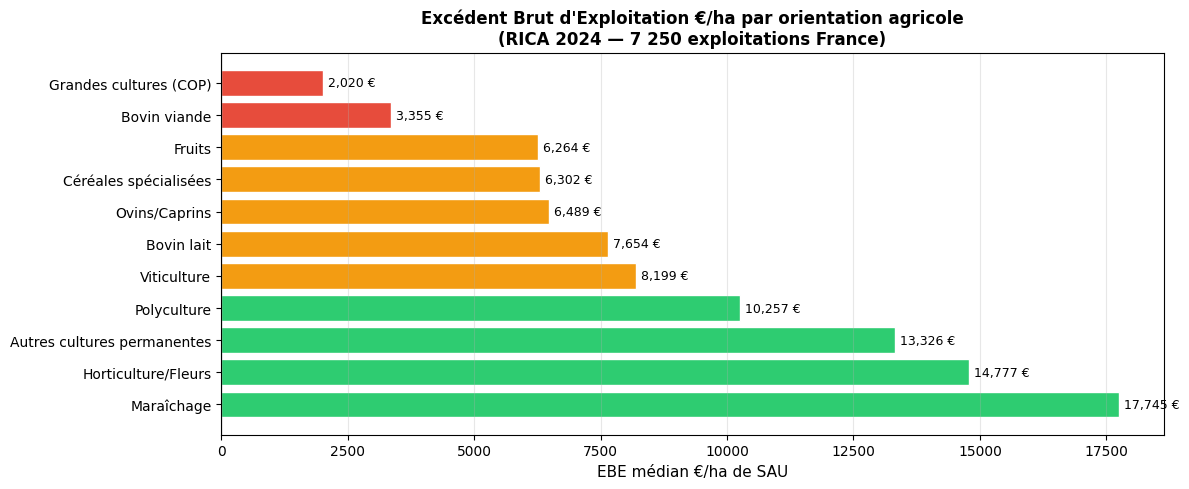


 Graphique sauvegardé : EBE_ha_par_OTEX.png


In [6]:
# ── EBE par ha de SAU par orientation ─────────────────────────────────────
otex_map = {
    15: 'Grandes cultures (COP)', 16: 'Céréales spécialisées',
    28: 'Maraîchage', 29: 'Horticulture/Fleurs',
    37: 'Viticulture', 38: 'Fruits',
    39: 'Autres cultures permanentes',
    45: 'Bovin lait', 46: 'Bovin viande',
    47: 'Ovins/Caprins', 50: 'Polyculture',
}

df_v = rica[(rica['SAUTI'] > 1) & (rica['EBEXP'].notna())].copy()
df_v['ebe_ha'] = df_v['EBEXP'] / df_v['SAUTI']
df_v = df_v[df_v['ebe_ha'].between(-5000, 80000)]

ebe_rows = []
for otex_code, label in otex_map.items():
    sub = df_v[df_v['OTEXE'] == otex_code]
    if len(sub) > 10:
        ebe_rows.append({
            'OTEX': otex_code, 'Orientation': label,
            'N': len(sub),
            'EBE_ha_moy': round(sub['ebe_ha'].mean(), 0),
            'EBE_ha_med': round(sub['ebe_ha'].median(), 0),
        })

df_ebe = pd.DataFrame(ebe_rows).sort_values('EBE_ha_med', ascending=False)
print('=== EBE €/ha par orientation (RICA 2024) ===')
print(df_ebe.to_string(index=False))

# ── Graphique ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if v >= 10000 else '#f39c12' if v >= 5000 else '#e74c3c'
          for v in df_ebe['EBE_ha_med']]
bars = ax.barh(df_ebe['Orientation'], df_ebe['EBE_ha_med'], color=colors, edgecolor='white')
ax.set_xlabel('EBE médian €/ha de SAU', fontsize=11)
ax.set_title('Excédent Brut d\'Exploitation €/ha par orientation agricole\n(RICA 2024 — 7 250 exploitations France)', 
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, df_ebe['EBE_ha_med']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{int(val):,} €', va='center', fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('EBE_ha_par_OTEX.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Graphique sauvegardé : EBE_ha_par_OTEX.png')

##  Cellule 6 — Construction de la table de scoring économique

| Score | Niveau | Seuil PB médian | Logique |
|-------|--------|-----------------|--------|
| **5** | Très haute valeur | > 15 000 €/ha | Maraîchage, arboriculture premium |
| **4** | Haute valeur | 8 000 – 15 000 €/ha | Cerises, abricots, vigne AOC |
| **3** | Valeur moyenne | 4 000 – 8 000 €/ha | Céréales, maïs, colza, PPAM |
| **2** | Faible valeur | 2 000 – 4 000 €/ha | Orge, triticale, luzerne |
| **1** | Très faible | < 2 000 €/ha | Prairies, fourrages, jachères |

In [14]:
# === EXTRACTION DES 76 CODES NON RECONNUS ===
# Exécuter après la cellule qui applique les scores aux parcelles

# Trouver tous les codes qui ne sont pas dans scoring_dict
codes_non_reconnus = rpg[~rpg['code_culture'].isin(scoring_dict.keys())]['code_culture'].value_counts()

# Afficher la liste complète
print(f"=== {len(codes_non_reconnus)} CODES NON RECONNUS ===\n")
print("CODE\tN_PARCELLES")
print("-" * 25)
for code, count in codes_non_reconnus.items():
    print(f"{code}\t{count}")

# Exporter en CSV pour me l'envoyer
codes_non_reconnus.to_csv('codes_non_reconnus.csv', header=['n_parcelles'])
print(f"\n✅ Fichier exporté : codes_non_reconnus.csv")

=== 76 CODES NON RECONNUS ===

CODE	N_PARCELLES
-------------------------
LAV	6151
TRU	2074
SAI	861
MLG	393
ARP	385
PVT	215
MDI	192
PEP	185
FLA	179
NOX	167
EPE	158
AIL	155
PWT	135
TTH	127
AAR	123
FLP	122
TRE	119
PME	101
TOM	93
MLO	89
VES	87
POT	79
PPP	74
CID	74
PEV	73
BFS	63
PHI	51
OIG	50
AME	47
PRF	45
MLF	43
CCN	37
FVL	37
AVH	35
FRA	33
BTP	28
LEC	27
MOT	27
BTN	24
OAG	24
MCR	23
CAR	18
NVT	15
PSL	15
MOH	15
AFG	13
PHF	12
SRS	11
LBF	11
TCR	11
GRA	10
CTG	9
PFR	9
HPC	9
PVP	8
CAG	7
MCS	7
MPC	7
PAG	6
ART	6
RDI	6
LIP	5
TTP	5
CML	5
NOS	5
CAH	4
CHU	4
PPR	4
POR	3
TBT	3
FEV	3
EPI	3
PHS	2
FNU	2
MLT	1
OHR	1

✅ Fichier exporté : codes_non_reconnus.csv


In [7]:
# ══════════════════════════════════════════════════════════════════════════
# FONCTION DE SCORING BASÉE SUR LES RÉSULTATS RICA
# ══════════════════════════════════════════════════════════════════════════

def get_score(pb_median):
    """Attribue un score 1-5 basé sur le PB médian €/ha."""
    if pb_median >= 15000: return 5
    elif pb_median >= 8000: return 4
    elif pb_median >= 4000: return 3
    elif pb_median >= 2000: return 2
    else: return 1

# ══════════════════════════════════════════════════════════════════════════
# GÉNÉRATION AUTOMATIQUE DU SCORING DEPUIS LES CALCULS RICA
# ══════════════════════════════════════════════════════════════════════════

scoring_dict = {}

# 1. Scores calculés depuis les données RICA
for _, row in df_rica_ref.iterrows():
    score = get_score(row['pb_ha_median'])
    for code_rpg in row['codes_RPG'].split(', '):
        scoring_dict[code_rpg.strip()] = score

print(f' {len(scoring_dict)} codes RPG scorés depuis les données RICA')

# 2. Ajouts manuels pour cultures absentes du RICA
# (Prairies, jachères, surfaces pastorales, etc.)

ajouts_manuels = {
    # Score 1 : Prairies permanentes, jachères, parcours
    'PPH': 1, 'PP': 1, 'PRL': 1, 'PRE': 1,      # Prairies permanentes
    'SPH': 1, 'SPL': 1, 'SPS': 1, 'SPE': 1,     # Surfaces pastorales
    'JAC': 1, 'JCH': 1, 'JNV': 1, 'JAE': 1, 'JG': 1, 'JNO': 1,  # Jachères
    'GEL': 1, 'SNE': 1, 'AUT': 1, 'DIV': 1,     # Gel, SNE, divers
    'BOP': 1, 'BRO': 1, 'LAN': 1, 'FRI': 1,     # Bois, landes, friches
    'PAT': 1, 'ALP': 1, 'EST': 1,               # Pâturages, alpages
    
    # Score 2 : Prairies temporaires, mélanges
    'PTH': 2, 'PTE': 2, 'PTR': 2,               # Prairies temporaires
    'MLC': 2, 'CIP': 2, 'ENR': 2,               # Mélanges, cultures intermédiaires
    'CBT': 2,                                    # Cultures biomasse
    'LOT': 2, 'MIN': 2,                          # Lotier, minette
    
    # Score 3 : Cultures spécifiques territoire
    'LIN': 3, 'CHV': 3,                          # Lin, chanvre
}

# Ajouter les codes manuels (sans écraser les codes RICA)
for code, score in ajouts_manuels.items():
    if code not in scoring_dict:
        scoring_dict[code] = score

print(f' {len(ajouts_manuels)} codes ajoutés manuellement (prairies, jachères...)')
print(f'\n TOTAL : {len(scoring_dict)} codes RPG dans le dictionnaire de scoring')

 81 codes RPG scorés depuis les données RICA
 36 codes ajoutés manuellement (prairies, jachères...)

 TOTAL : 117 codes RPG dans le dictionnaire de scoring


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# CRÉATION DE LA TABLE DE RÉFÉRENCE
# ══════════════════════════════════════════════════════════════════════════

niveau_map = {
    5: ' Très haute (>15k€/ha)',
    4: 'Haute (8-15k€/ha)',
    3: 'Moyenne (4-8k€/ha)',
    2: 'Faible (2-4k€/ha)',
    1: 'Très faible (<2k€/ha)'
}

df_scoring = pd.DataFrame([
    {'CODE_CULTURE': code, 'score_eco': score, 'niveau': niveau_map[score]}
    for code, score in sorted(scoring_dict.items(), key=lambda x: (-x[1], x[0]))
])

print('=== Table de scoring économique ===')
print(df_scoring.groupby(['score_eco', 'niveau']).size()
      .reset_index(name='nb_codes').to_string(index=False))

# Sauvegarder le CSV
df_scoring.to_csv(OUTPUT_CSV, sep=';', index=False, encoding='utf-8-sig')
print(f'\n✅ Table sauvegardée : {OUTPUT_CSV}')

=== Table de scoring économique ===
 score_eco                 niveau  nb_codes
         1  Très faible (<2k€/ha)        44
         2      Faible (2-4k€/ha)        28
         3     Moyenne (4-8k€/ha)        19
         4      Haute (8-15k€/ha)        12
         5  Très haute (>15k€/ha)        14

✅ Table sauvegardée : scoring_IQE_RICA2024.csv


## 🗺️ Cellule 7 — Chargement du RPG PAC

In [9]:
# ── Charger le RPG ─────────────────────────────────────────────────────────
print(f'Chargement : {RPG_PATH}')
rpg = gpd.read_file(RPG_PATH)

print(f'\n✅ RPG chargé : {len(rpg):,} parcelles')
print(f'   CRS : {rpg.crs}')
print(f'   Colonnes : {list(rpg.columns)}')
print(f'   Surface totale : {rpg.geometry.area.sum()/10000:,.0f} ha')

# ── Identifier la colonne CODE_CULTURE ─────────────────────────────────────
code_col = None
for candidate in ['CODE_CULTURE', 'code_cultu', 'CODE_CULTU', 'code_culture', 'CULTURE']:
    if candidate in rpg.columns:
        code_col = candidate
        break

if code_col:
    print(f'\n✅ Colonne culture trouvée : "{code_col}"')
    print(f'   Top 15 codes culture :')
    print(rpg[code_col].value_counts().head(15).to_string())
else:
    print('\n⚠️ Colonne culture non trouvée !')
    print('   Colonnes disponibles :', list(rpg.columns))
    code_col = 'CODE_CULTURE'  # valeur par défaut

Chargement : RPG_pac_RPB.gpkg

✅ RPG chargé : 65,067 parcelles
   CRS : EPSG:3057
   Colonnes : ['code_culture', 'code_group', 'surf_parc', 'culture_d1', 'culture_d2', 'cat_cult_p', 'layer', 'path', 'insee', 'nom', 'wikipedia', 'surf_ha', 'DEMO_INSEE', 'DEMO_INS_1', 'DEMO_INS_2', 'DEMO_INS_3', 'DEMO_INS_4', 'DEMO_INS_5', 'DEMO_INS_6', 'DEMO_INS_7', 'DEMO_INS_8', 'DEMO_INS_9', 'DEMO_INS10', 'DEMO_INS11', 'DEMO_INS12', 'DEMO_INS13', 'DEMO_INS14', 'DEMO_INS15', 'DEMO_INS16', 'DEMO_INS17', 'geometry']
   Surface totale : 109,921 ha

✅ Colonne culture trouvée : "code_culture"
   Top 15 codes culture :
code_culture
VRC    15095
LAV     6151
PPH     5697
BOR     4652
SPH     2753
LUZ     2675
OLI     2621
VRG     2252
JAC     2239
TRU     2074
PTR     1988
BTA     1824
BDH     1740
SPL     1634
BTH     1563


## 🔗 Cellule 8 — Attribution du scoring économique aux parcelles RPG

In [10]:
# ══════════════════════════════════════════════════════════════════════════
# JOINTURE : CODE_CULTURE → SCORE
# ══════════════════════════════════════════════════════════════════════════

# Attribuer le score (codes non reconnus → score 1 par défaut)
rpg['score_eco'] = rpg[code_col].map(scoring_dict).fillna(1).astype(int)

# Ajouter le libellé
rpg['niveau_eco'] = rpg['score_eco'].map({
    5: 'Très haute valeur',
    4: 'Haute valeur',
    3: 'Valeur moyenne',
    2: 'Faible valeur',
    1: 'Très faible valeur'
})

# Calculer l'IQE normalisé (0-1)
rpg['IQE'] = (rpg['score_eco'] - 1) / 4

# Surface en hectares
rpg['surf_ha'] = rpg.geometry.area / 10000

# ══════════════════════════════════════════════════════════════════════════
# STATISTIQUES
# ══════════════════════════════════════════════════════════════════════════

print('=== Distribution du score économique sur les parcelles RPG ===')
stats = rpg.groupby(['score_eco', 'niveau_eco']).agg(
    nb_parcelles=('score_eco', 'count'),
    surface_ha=('surf_ha', 'sum')
).reset_index()
stats['surface_ha'] = stats['surface_ha'].round(0).astype(int)
stats['pct_surface'] = (stats['surface_ha'] / stats['surface_ha'].sum() * 100).round(1)
print(stats.to_string(index=False))

# IQE moyen
print(f'\n📈 IQE moyen du territoire : {rpg["IQE"].mean():.3f}')
print(f'   IQE pondéré par surface : {(rpg["IQE"] * rpg["surf_ha"]).sum() / rpg["surf_ha"].sum():.3f}')

=== Distribution du score économique sur les parcelles RPG ===
 score_eco         niveau_eco  nb_parcelles  surface_ha  pct_surface
         1 Très faible valeur         30822       58787         53.5
         2      Faible valeur          9914       13744         12.5
         3     Valeur moyenne          6453       13390         12.2
         4       Haute valeur         17463       23077         21.0
         5  Très haute valeur           415         924          0.8

📈 IQE moyen du territoire : 0.295
   IQE pondéré par surface : 0.258


In [11]:
# ══════════════════════════════════════════════════════════════════════════
# CODES NON RECONNUS
# ══════════════════════════════════════════════════════════════════════════

codes_inconnus = rpg[~rpg[code_col].isin(scoring_dict.keys())][code_col].value_counts()

if len(codes_inconnus) > 0:
    print(f'⚠️ {len(codes_inconnus)} codes culture non reconnus (scorés à 1 par défaut) :')
    print(codes_inconnus.head(25).to_string())
    print('\n→ Ces codes peuvent être ajoutés au dictionnaire scoring_dict')
else:
    print('✅ Tous les codes culture ont été reconnus !')

⚠️ 76 codes culture non reconnus (scorés à 1 par défaut) :
code_culture
LAV    6151
TRU    2074
SAI     861
MLG     393
ARP     385
PVT     215
MDI     192
PEP     185
FLA     179
NOX     167
EPE     158
AIL     155
PWT     135
TTH     127
AAR     123
FLP     122
TRE     119
PME     101
TOM      93
MLO      89
VES      87
POT      79
PPP      74
CID      74
PEV      73

→ Ces codes peuvent être ajoutés au dictionnaire scoring_dict


## 🗺️ Cellule 9 — Visualisation cartographique

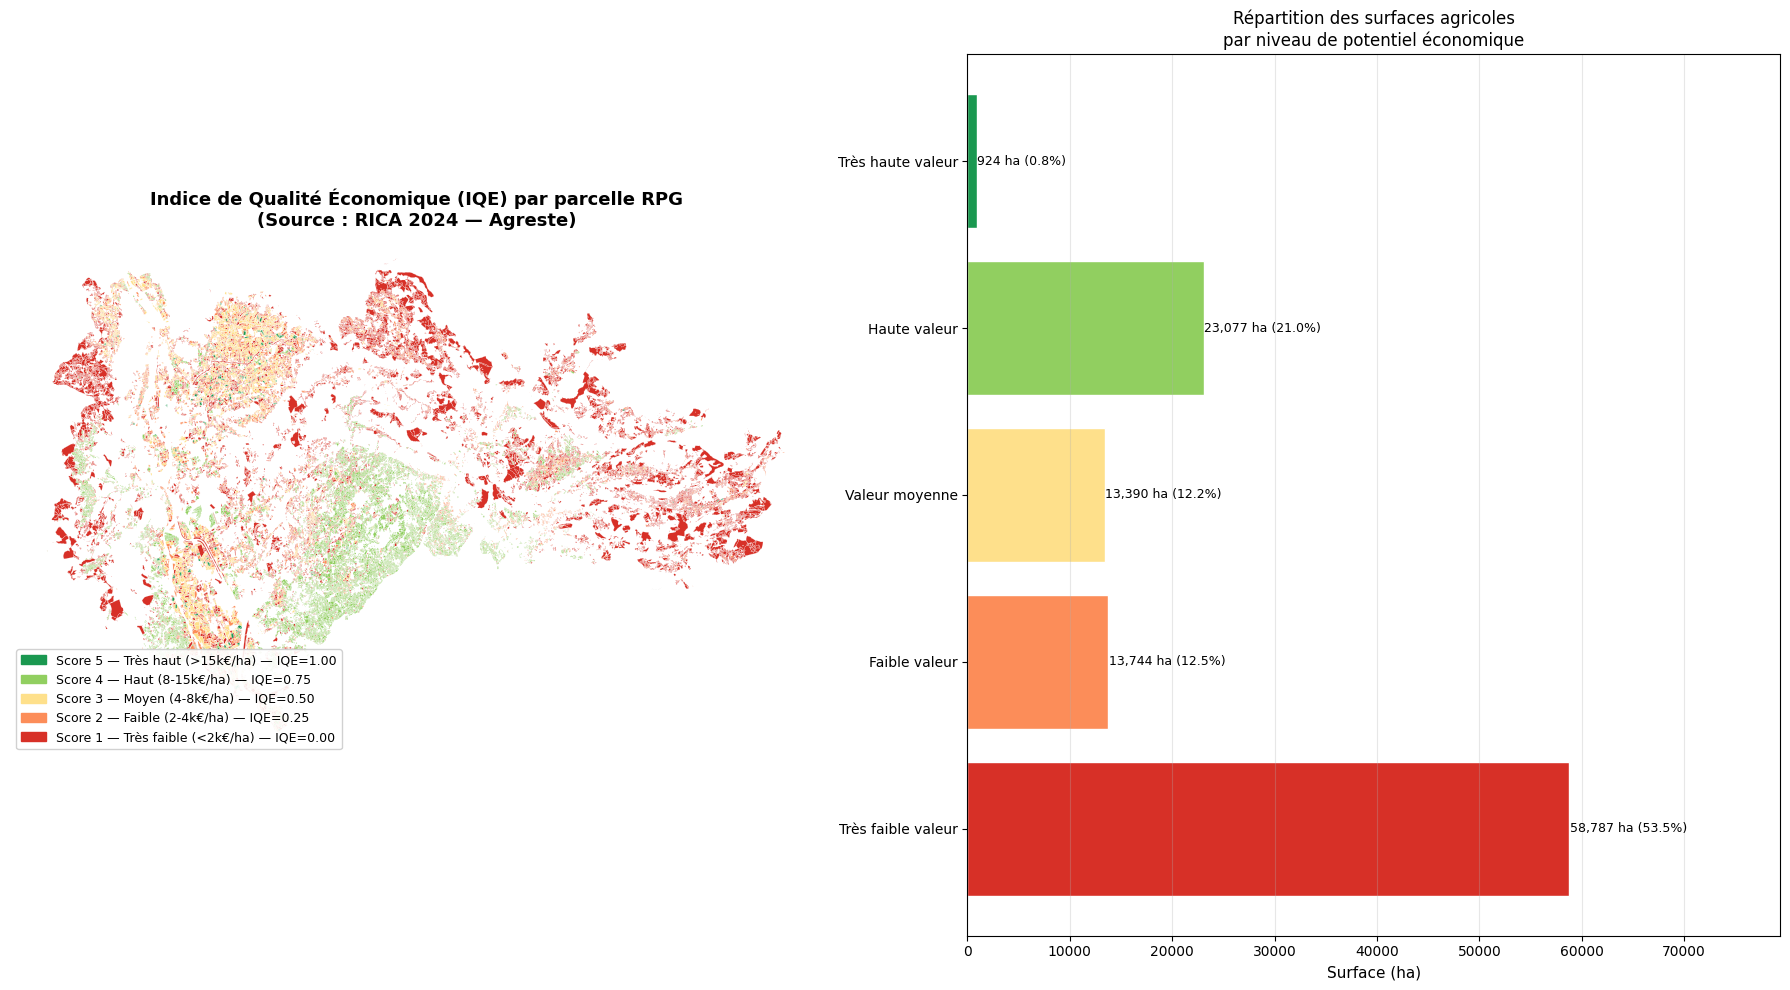

✅ Carte sauvegardée : carte_IQE_SCOT_RPB.png


In [12]:
# ── Palette de couleurs ───────────────────────────────────────────────────
palette = {
    1: '#d73027',   # rouge — très faible
    2: '#fc8d59',   # orange — faible
    3: '#fee08b',   # jaune — moyenne
    4: '#91cf60',   # vert clair — haute
    5: '#1a9850',   # vert foncé — très haute
}
rpg['color'] = rpg['score_eco'].map(palette)

# ── Carte ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Carte principale
ax1 = axes[0]
for score in [1, 2, 3, 4, 5]:
    subset = rpg[rpg['score_eco'] == score]
    if len(subset) > 0:
        subset.plot(ax=ax1, color=palette[score], linewidth=0.1, edgecolor='white')

ax1.set_title('Indice de Qualité Économique (IQE) par parcelle RPG\n(Source : RICA 2024 — Agreste)',
              fontsize=13, fontweight='bold')
ax1.set_axis_off()

# Légende
labels = {
    1: 'Score 1 — Très faible (<2k€/ha) — IQE=0.00',
    2: 'Score 2 — Faible (2-4k€/ha) — IQE=0.25',
    3: 'Score 3 — Moyen (4-8k€/ha) — IQE=0.50',
    4: 'Score 4 — Haut (8-15k€/ha) — IQE=0.75',
    5: 'Score 5 — Très haut (>15k€/ha) — IQE=1.00',
}
patches = [mpatches.Patch(color=palette[s], label=labels[s]) for s in [5,4,3,2,1]]
ax1.legend(handles=patches, loc='lower left', fontsize=9, framealpha=0.9)

# Graphique en barres
ax2 = axes[1]
colors_bar = [palette[s] for s in stats['score_eco']]
bars = ax2.barh(stats['niveau_eco'], stats['surface_ha'], color=colors_bar, edgecolor='white')
ax2.set_xlabel('Surface (ha)', fontsize=11)
ax2.set_title('Répartition des surfaces agricoles\npar niveau de potentiel économique', fontsize=12)
for bar, row in zip(bars, stats.itertuples()):
    ax2.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{row.surface_ha:,} ha ({row.pct_surface}%)', va='center', fontsize=9)
ax2.grid(axis='x', alpha=0.3)
ax2.set_xlim(0, stats['surface_ha'].max() * 1.35)

plt.tight_layout()
plt.savefig('carte_IQE_SCOT_RPB.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Carte sauvegardée : carte_IQE_SCOT_RPB.png')

## 💾 Cellule 10 — Export du GeoPackage enrichi

In [13]:
# ── Supprimer la colonne color (non compatible GPKG) ─────────────────────
cols_export = [c for c in rpg.columns if c != 'color']
rpg_export = rpg[cols_export].copy()

# ── Export GeoPackage ─────────────────────────────────────────────────────
rpg_export.to_file(OUTPUT_GPK, driver='GPKG')

print(f'✅ GeoPackage exporté : {OUTPUT_GPK}')
print(f'   {len(rpg_export):,} parcelles')
print(f'   Nouvelles colonnes : score_eco (1-5), niveau_eco, IQE (0-1), surf_ha')
print()

# ── Récapitulatif ─────────────────────────────────────────────────────────
print('=== RÉCAPITULATIF DES FICHIERS PRODUITS ===')
for f in [OUTPUT_GPK, OUTPUT_CSV, 'carte_IQE_SCOT_RPB.png', 'EBE_ha_par_OTEX.png']:
    if os.path.exists(f):
        print(f'  ✅ {f}  ({os.path.getsize(f)/1e6:.1f} Mo)')

print()
print('=== UTILISATION DANS QGIS ===')
print(f'  1. Ouvrir {OUTPUT_GPK} dans QGIS')
print('  2. Symbologie → Catégoriser → Champ : score_eco (ou IQE)')
print('  3. Score 5 / IQE=1 = vert foncé (très haute valeur agricole)')
print('  4. Score 1 / IQE=0 = rouge (faible potentiel économique)')
print()
print('=== INTÉGRATION IQAE ===')
print('  L\'IQE calculé ici représente 40% de l\'IQAE final :')
print('  IQAE = 0.60 × IQA + 0.40 × IQE')
print('  → Croiser avec le notebook IQA (qualité agronomique des sols)')

✅ GeoPackage exporté : RPG_IQE_SCOT_RPB.gpkg
   65,067 parcelles
   Nouvelles colonnes : score_eco (1-5), niveau_eco, IQE (0-1), surf_ha

=== RÉCAPITULATIF DES FICHIERS PRODUITS ===
  ✅ RPG_IQE_SCOT_RPB.gpkg  (68.7 Mo)
  ✅ scoring_IQE_RICA2024.csv  (0.0 Mo)
  ✅ carte_IQE_SCOT_RPB.png  (0.8 Mo)
  ✅ EBE_ha_par_OTEX.png  (0.1 Mo)

=== UTILISATION DANS QGIS ===
  1. Ouvrir RPG_IQE_SCOT_RPB.gpkg dans QGIS
  2. Symbologie → Catégoriser → Champ : score_eco (ou IQE)
  3. Score 5 / IQE=1 = vert foncé (très haute valeur agricole)
  4. Score 1 / IQE=0 = rouge (faible potentiel économique)

=== INTÉGRATION IQAE ===
  L'IQE calculé ici représente 40% de l'IQAE final :
  IQAE = 0.60 × IQA + 0.40 × IQE
  → Croiser avec le notebook IQA (qualité agronomique des sols)


## 📚 Références bibliographiques

| Source | Description | Utilisation |
|--------|-------------|-------------|
| **Agreste — RICA 2024** | Réseau d'Information Comptable Agricole, Ministère de l'Agriculture. Micro-données 7 250 exploitations France entière. | Calcul du Produit Brut médian €/ha par culture (variables `PBV3XXXX` / `SUT3XXXX`) |
| **CGAAER 2020** | Conseil Général de l'Alimentation, de l'Agriculture et des Espaces Ruraux — *Méthodologie de calcul de l'IQAE* | Pondération IQA (60%) / IQE (40%) et seuils de scoring |
| **INRAE** | Chatellier V. — *Résultat économique des exploitations agricoles et revenu des agriculteurs* | Validation des ordres de grandeur PB/ha et EBE/ha |
| **Chambre d'Agriculture Drôme** | Références technico-économiques locales : lavande/lavandin, olives, truffes, arboriculture | Scoring des cultures PPAM spécifiques au territoire SCOT RPB |
| **IGN — RPG PAC 2023** | Registre Parcellaire Graphique, déclarations PAC | Données géographiques des parcelles agricoles |

---

## Méthodologie détaillée

### 1. Extraction des données RICA
Pour chaque culture, on extrait :
- `PBV3XXXX` : Produit Brut Végétal (€)
- `SUT3XXXX` : Surface cultivée (ha)

### 2. Calcul du PB/ha
```
PB_ha = PBV3XXXX / SUT3XXXX
```
On utilise la **médiane** (robuste aux outliers) après filtrage des valeurs aberrantes (100 < PB/ha < 300 000 €/ha).

### 3. Attribution du score
```python
if pb_median >= 15000: score = 5
elif pb_median >= 8000: score = 4
elif pb_median >= 4000: score = 3
elif pb_median >= 2000: score = 2
else: score = 1
```

### 4. Normalisation IQE
```
IQE = (score - 1) / 4
```

---
*Ce notebook a été produit dans le cadre du projet « Évaluation du potentiel foncier agricole dans le SCOT RPB », Master GEORISK, Université Gustave Eiffel, 2025–2026.*